In [1]:
"""
exploration: 
  a robot is somewhere on a line, its position is the state 'x'.

  there's a prior p(x), a belief about position before measuring. make it a gaussian centered at 0, with some standard deviation 's_location' (indicating that the position is first believed to be about at 0 with some uncertainty of 's_location')

  theres also a sensor model (likelihood) p(y | x). which gives the probability of a sensor reading 'y' given a true position 'x'. the sensor should return a position corrupted by gaussian noise. p(y | x) is a gaussian in x, centered at the measurement y, with the sensor's noise standard deviation of 's_sensor'. so if the sensor reads y = 2, the likelihood is a gaussian bump centered at x = 2

  task: say a measurement 'y' comes in (lets say 2). compute the posterior p(x | y) using Bayes' rule.
"""

%run -i ../1.definitions/explore.ipynb
%matplotlib widget

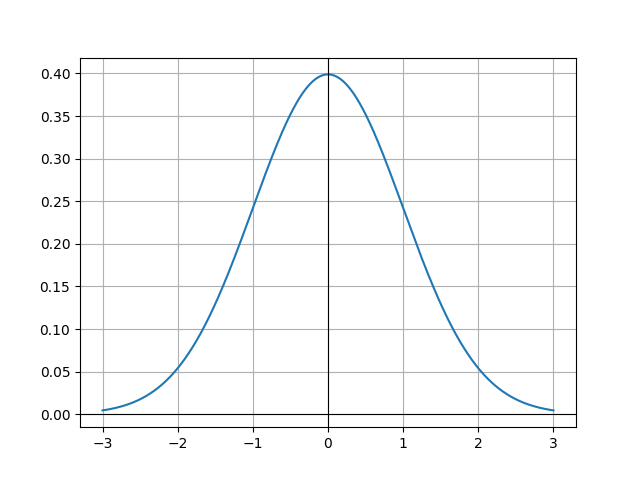

1.0


In [2]:
if __name__ == '__main__' and '__file__' not in globals():
  std_normal_dist = _make_gaussian(mean = 0.0, stdev = 1.0)
  _plot_function(std_normal_dist, -3, 3)
  print(_simpson_integrate(std_normal_dist))

In [3]:
def _make_gaussian_sensor_model(noise = 1.0):
  def f(y, x):
    g = _make_gaussian(x, noise)
    return g(y)
  return f

In [4]:
def _make_posterior(location_model, sensor_model):
  denom = {}
  def posterior_prob(x, y):
    def numer(_x):
      return sensor_model(y, _x) * location_model(_x)
    if y not in denom:
      denom[y] = _simpson_integrate(numer)
    return numer(x) / denom[y]
  return posterior_prob

In [5]:
def _plot_surface(g, x_lab = 'x', y_lab = 'y', ax_lo=-5, ax_hi=5, ay_lo=-5, ay_hi=5, n=60):
  xs = np.linspace(ax_lo, ax_hi, n+1)
  ys = np.linspace(ay_lo, ay_hi, n+1)
  X, Y = np.meshgrid(xs, ys)
  Z = np.array([[g(x, y) for x in xs] for y in ys])
  ax = plt.figure().add_subplot(projection='3d')
  ax.plot_surface(X, Y, Z)
  ax.set_xlabel(x_lab)
  ax.set_ylabel(y_lab)
  ax.set_zlabel('posterior')
  plt.show()

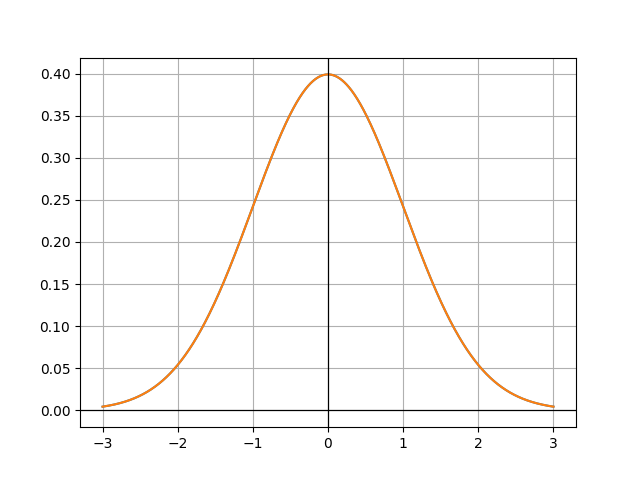

In [6]:
if __name__ == '__main__' and '__file__' not in globals():
  location_guess = _make_gaussian(0, 1)
  _plot_function(location_guess, -3, 3)

  sensor_model = _make_gaussian_sensor_model()
  acquired_sensor_reading = 2.0

0.5641895835477563


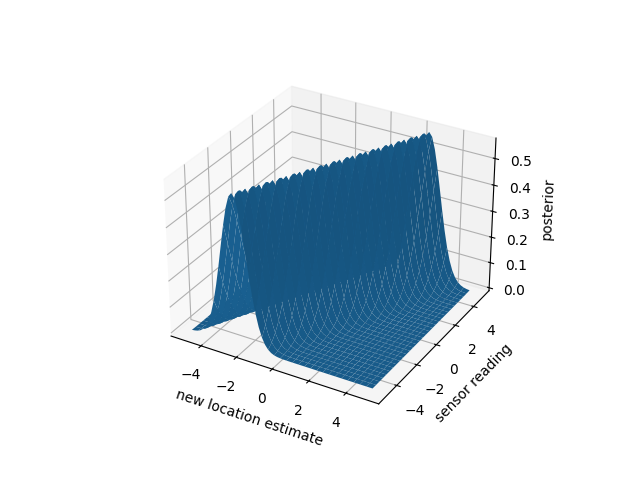

In [7]:
if __name__ == '__main__' and '__file__' not in globals():
  posterior_location_guess = _make_posterior(location_guess, sensor_model)
  print(posterior_location_guess(1.0, 2.0))

  _plot_surface(posterior_location_guess, 'new location estimate', 'sensor reading')